<a href="https://colab.research.google.com/github/nimtruly/mlp-ka2/blob/main/ka2_16_0-6567.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KA2

In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (90000, 14)
Test shape: (30000, 13)


In [4]:
train_df.head()

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0


In [5]:
test_df.head()

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
0,0,15765283,T'ien,645.0,France,Male,30.0,10,0.00,2.0,0.0,0.0,85901.09
1,1,15660157,Macleod,641.0,France,Male,37.0,10,146573.68,3.0,1.0,0.0,168023.72
2,2,15621267,Ejimofor,637.0,France,Female,32.0,6,0.00,1.0,0.0,0.0,148769.08
3,3,15651280,Nnaife,714.0,France,Male,37.0,7,0.00,2.0,1.0,0.0,172576.22
4,4,15764294,Ifeatu,716.0,Germany,Male,31.0,4,98899.91,1.0,1.0,1.0,47832.82


# 1. Identify data types of different columns
The data types of the different columns are identified and explicitly stated in the notebook

In [6]:
train_df.info()
# print(train_df.dtypes)
# train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  object 
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  object 
 5   gender            90000 non-null  object 
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), object(3)
memory usage: 9.6+ MB


# 2. Present descriptive statistics of numerical columns
Details such as min value, max value, mean and median for each numerical column is presented

In [7]:
# Display descriptive statistics
print(train_df.describe().T[["min", "max", "mean", "50%"]])
# 50% = median

                          min          max          mean          50%
id                       0.00     89999.00  4.499950e+04     44999.50
customer_id       15565701.00  15815690.00  1.569209e+07  15690164.00
credit_score           350.00       850.00  6.564971e+02       659.00
age                     18.00        92.00  3.811953e+01        37.00
tenure                   0.00        10.00  5.017022e+00         5.00
acc_balance              0.00    250898.09  5.545673e+04         0.00
prod_count               1.00         4.00  1.552932e+00         2.00
has_card                 0.00         1.00  7.542889e-01         1.00
is_active                0.00         1.00  4.971778e-01         0.00
estimated_salary        11.58    199992.48  1.123947e+05    117505.07
exit_status              0.00         1.00  2.116000e-01         0.00


In [8]:
# # Define numerical feature columns
# num_cols = ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'has_card', 'is_active', 'estimated_salary']

# # Calculate descriptive statistics
# desc_stats = train_df[num_cols].describe().T
# desc_stats['median'] = train_df[num_cols].median()

# # Format descriptive statistics table
# stats_table = desc_stats[['min', 'max', 'mean', 'median', 'std']]
# display(stats_table)


# 3. Identify and handle the missing values
Missing values are identified and are dropped or imputed

In [9]:
# Check for missing values
train_df.isnull().sum()

,0
id,0
customer_id,0
last_name,0
credit_score,9556
country,6021
gender,0
age,0
tenure,0
acc_balance,7257
prod_count,4863


In [10]:
# Fill numerical missing values with the median
train_df.fillna(train_df.median(numeric_only=True), inplace=True)
#median for numerical columns as it is less affected by outliers

In [11]:
# Check if any missing values remain
train_df.isnull().sum()

,0
id,0
customer_id,0
last_name,0
credit_score,0
country,6021
gender,0
age,0
tenure,0
acc_balance,0
prod_count,0


In [12]:
# Fill remaining missing values with the most common value
train_df.fillna(train_df.mode().iloc[0], inplace=True)
# mode for categorical columns as it is the most common category

In [13]:
# Confirm that there are no missing values
train_df.isnull().sum()

,0
id,0
customer_id,0
last_name,0
credit_score,0
country,0
gender,0
age,0
tenure,0
acc_balance,0
prod_count,0


In [14]:
# train_df.isnull()

# 4. Identify and handle duplicates
Duplicates are identified and are dropped if they exist

In [15]:
# Check for duplicate rows
# train_df.duplicated()
train_df.duplicated().sum()


np.int64(0)

In [16]:
print("No duplicates found")

No duplicates found


# 5. Identify and handle outliers
Outliers are identified and explanation for retaining / dropping is provided

In [17]:
# Check for outliers using the IQR method
for col in train_df.select_dtypes(include=np.number).columns:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    outliers = (
        (train_df[col] < Q1 - 1.5 * IQR) | (train_df[col] > Q3 + 1.5 * IQR)
    ).sum()

    print(col, ":", outliers)


id : 0
customer_id : 0
credit_score : 605
age : 3411
tenure : 0
acc_balance : 0
prod_count : 263
has_card : 22114
is_active : 0
estimated_salary : 0
exit_status : 19044


In [18]:
print((train_df[col] < Q1 - 1.5 * IQR).sum())
print((train_df[col] > Q3 + 1.5 * IQR).sum())

0
19044


In [19]:
# # Import visualization libraries right before plotting
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# warnings.filterwarnings('ignore')

# # Detect Outliers using IQR method
# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# axes = axes.flatten()

# for i, col in enumerate(num_cols):
#     sns.boxplot(y=train_df[col], ax=axes[i], color='skyblue')
#     axes[i].set_title(f'Boxplot of {col}')

# plt.tight_layout()
# plt.show()

# # Calculate IQR bounds
# for col in ['credit_score', 'age', 'acc_balance', 'estimated_salary']:
#     Q1 = train_df[col].quantile(0.25)
#     Q3 = train_df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
#     print(f"Feature '{col}': {len(outliers)} outliers detected outside [{lower_bound:.2f}, {upper_bound:.2f}]")


Outliers were identified using the IQR method. The identified outliers were retained because they may represent valid customer information and could contain useful information for classification.

#6. Present at least three visualizations and provide insights for the same
At least three visualizations on the data is presented

In [20]:
# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

Visualization 1: Exit status distribution

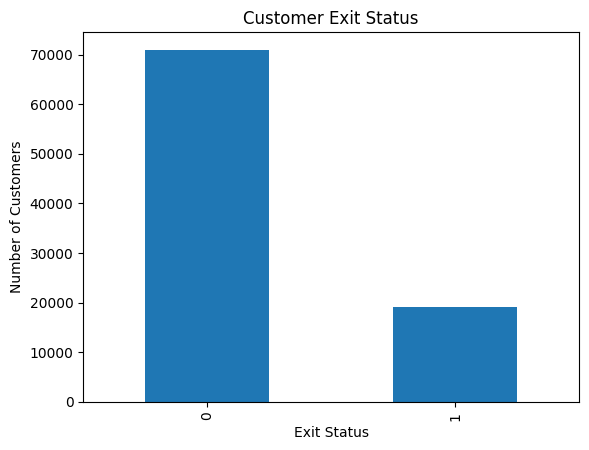

In [21]:
# Show the distribution of customers who exited
train_df["exit_status"].value_counts().plot(kind="bar")

plt.xlabel("Exit Status")
plt.ylabel("Number of Customers")
plt.title("Customer Exit Status")
plt.show()

Visualization 2: Age distribution

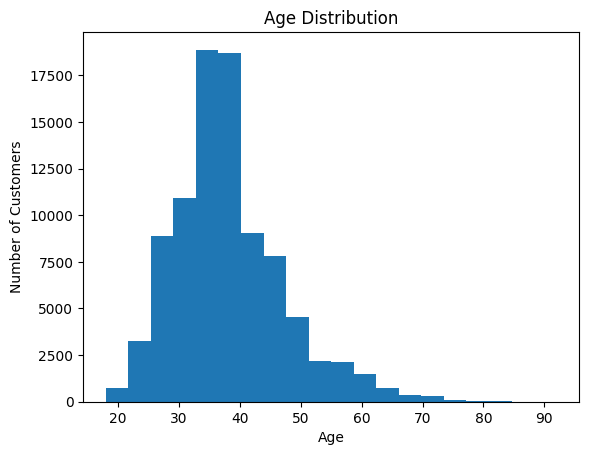

In [22]:
# Show the distribution of customer ages
train_df["age"].plot(kind="hist", bins=20)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")
plt.show()

Visualization 3: Target Distribution

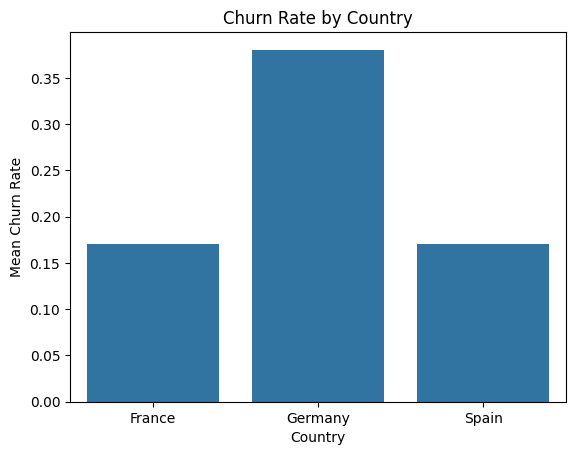

In [23]:
# Show churn rate by country
country_churn = train_df.groupby("country")["exit_status"].mean().reset_index()

sns.barplot(x="country", y="exit_status", data=country_churn)

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Mean Churn Rate")
plt.show()

Visualization 4: Churn Rate by Country

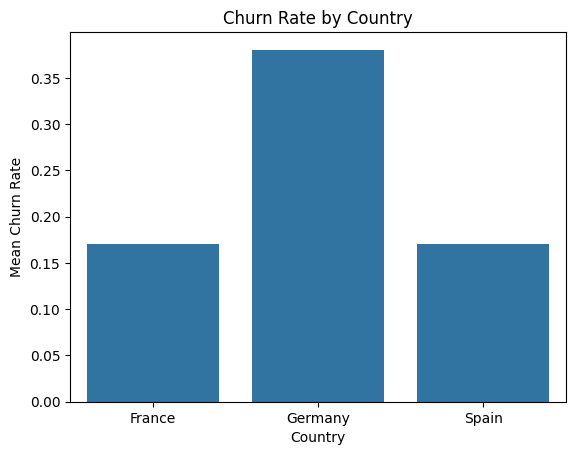

In [24]:
# Show churn rate by country
country_churn = train_df.groupby("country")["exit_status"].mean().reset_index()

sns.barplot(x="country", y="exit_status", data=country_churn)

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Mean Churn Rate")
plt.show()

Visualization 5: Churn Rate by Gender

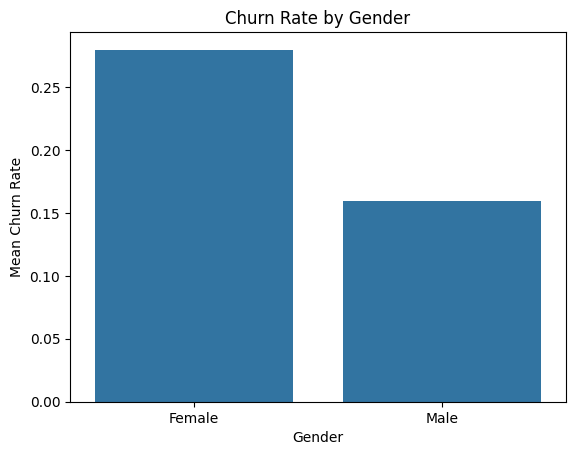

In [25]:
# Show churn rate by gender
gender_churn = train_df.groupby("gender")["exit_status"].mean().reset_index()

sns.barplot(x="gender", y="exit_status", data=gender_churn)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Churn Rate")
plt.show()

Visualization 6: Account balance by exit status

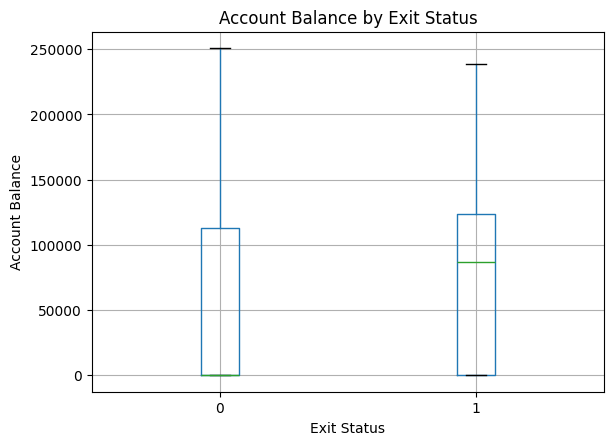

In [26]:
# Compare account balance for customers who stayed and exited
train_df.boxplot(column="acc_balance", by="exit_status")

plt.xlabel("Exit Status")
plt.ylabel("Account Balance")
plt.title("Account Balance by Exit Status")
plt.suptitle("")
plt.show()

# 7. Scale Numerical features and Encode Categorical features
Explanation for scaling (or not scaling) and encoding (or not encoding) is provided

In [27]:
train_df.head(2)

,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0


In [28]:
# Separate features and target
X = train_df.drop("exit_status", axis=1)
y = train_df["exit_status"]

In [53]:
# X.head()

In [54]:
# y.head()

In [31]:
# Remove identifier columns
X = X.drop(["id", "customer_id"], axis=1)
test_features = test_df.drop(["id", "customer_id"], axis=1)
# making another test data without the identifiers

In [32]:
# Encode categorical features
X = pd.get_dummies(X, columns=["country", "gender"])

test_features = pd.get_dummies(test_features, columns=["country", "gender"])

test_features = test_features.reindex(columns=X.columns, fill_value=0)

In [34]:
from sklearn.preprocessing import StandardScaler

# Scale numerical features
num_cols = ["credit_score", "age", "tenure", "acc_balance", "prod_count", "estimated_salary"]

scaler = StandardScaler()

X[num_cols] = scaler.fit_transform(X[num_cols])
test_features[num_cols] = scaler.transform(test_features[num_cols])

In [35]:
# Check the prepared features
print(X.dtypes)

last_name            object
credit_score        float64
age                 float64
tenure              float64
acc_balance         float64
prod_count          float64
has_card            float64
is_active           float64
estimated_salary    float64
country_France         bool
country_Germany        bool
country_Spain          bool
gender_Female          bool
gender_Male            bool
dtype: object


The numerical features were scaled using StandardScaler so that they have a similar range. The categorical features country and gender were converted into numerical columns using one-hot encoding. The last_name column was kept separately because it will be converted using target encoding during model building. The id and customer_id columns were removed because they are identifiers and do not provide useful information for prediction.

# 8. Model Building (at least 7)
7 different types of models are trained on the data


In [51]:
X.head(2)

,last_name,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,Iredale,-1.292251,-1.142785,-1.432197,1.595092,-1.063766,1.0,1.0,-0.889040,True,False,False,False,True
1,Hs?,0.492209,-0.126427,0.706995,1.023477,0.779566,0.0,0.0,1.397994,True,False,False,True,False


In [52]:
y.head()

,exit_status
0,0
1,0
2,0
3,0
4,0


In [38]:
# Split the data into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print(X.shape, y.shape)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(90000, 14) (90000,)
(72000, 14) (72000,)
(18000, 14) (18000,)


In [43]:
# Create out-of-fold target encoding for last_name
from sklearn.model_selection import KFold

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train["last_name_te"] = 0.0

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, valid_index in kf.split(X_train):

    temp = pd.DataFrame({
        "last_name": X_train.loc[train_index, "last_name"],
        "target": y_train.loc[train_index]
    })

    stats = temp.groupby("last_name")["target"].agg(["mean", "count"])

    mean = (
        stats["count"] * stats["mean"] + 20 * y_train.loc[train_index].mean()
    ) / (stats["count"] + 20)

    X_train.loc[valid_index, "last_name_te"] = (
        X_train.loc[valid_index, "last_name"]
        .map(mean)
        .fillna(y_train.loc[train_index].mean())
    )

In [44]:
# Encode last_name in the validation data
stats = pd.DataFrame({
    "last_name": X_train["last_name"],
    "target": y_train
}).groupby("last_name")["target"].agg(["mean", "count"])

mean = (
    stats["count"] * stats["mean"] + 20 * y_train.mean()
) / (stats["count"] + 20)

X_test["last_name_te"] = (
    X_test["last_name"]
    .map(mean)
    .fillna(y_train.mean())
)

In [45]:
# Remove the original text column
X_train = X_train.drop("last_name", axis=1)
X_test = X_test.drop("last_name", axis=1)

In [50]:
X_train.head(2)

,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male,last_name_te
0,0.703701,-1.255713,-0.006069,-0.821438,0.779566,1.0,0.0,0.658532,True,False,False,False,True,0.158327
1,1.285303,-0.126427,1.063527,0.932883,0.779566,1.0,1.0,-0.370489,False,True,False,False,True,0.174689


In [59]:
y_train.head(2)

,exit_status
0,0
1,0


In [49]:
X_test.head(2)

,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male,last_name_te
0,1.298521,-0.126427,1.063527,-0.821438,-1.063766,1.0,0.0,0.723349,True,False,False,False,True,0.249453
1,0.029572,-0.239356,0.350463,0.991389,0.779566,0.0,0.0,-0.039185,True,False,False,True,False,0.134950


In [60]:
# model 1: log reg
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

print("Logistic Regression F1:", f1_score(y_test, pred1))

Logistic Regression F1: 0.4881253158160687


In [61]:
# model 2:knn
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=15)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

print("KNN F1:", f1_score(y_test, pred2))

KNN F1: 0.5786612828078894


In [62]:
#model 3: dt
from sklearn.tree import DecisionTreeClassifier

model3 = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

print("Decision Tree F1:", f1_score(y_test, pred3))

Decision Tree F1: 0.6060152626066138


In [63]:
#model 4: random
from sklearn.ensemble import RandomForestClassifier

model4 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model4.fit(X_train, y_train)

pred4 = model4.predict(X_test)

print("Random Forest F1:", f1_score(y_test, pred4))

Random Forest F1: 0.5809399477806788


In [64]:
# model 5: et
from sklearn.ensemble import ExtraTreesClassifier

model5 = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model5.fit(X_train, y_train)
pred5 = model5.predict(X_test)

print("Extra Trees F1:", f1_score(y_test, pred5))

Extra Trees F1: 0.4843377908041766


In [65]:
# model 6: grad boost
from sklearn.ensemble import GradientBoostingClassifier

model6 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model6.fit(X_train, y_train)
pred6 = model6.predict(X_test)

print("Gradient Boosting F1:", f1_score(y_test, pred6))

Gradient Boosting F1: 0.5895582329317269


In [66]:
# model 7: hist grad
from sklearn.ensemble import HistGradientBoostingClassifier

model7 = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model7.fit(X_train, y_train)

pred7 = model7.predict(X_test)

print("HistGradientBoosting F1:", f1_score(y_test, pred7))

HistGradientBoosting F1: 0.6160822249093107


# 9. Hyperparameter Tuning on any 3 of the models
Hyperparameter tuning is done on 3 of the models

In [68]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [70]:
#tune dt
params1 = {
    "max_depth": [6, 8, 10]
}
grid1 = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params1,
    cv=3,
    scoring="f1"
)

grid1.fit(X_train, y_train)
print("Best parameters:", grid1.best_params_)

Best parameters: {'max_depth': 10}


In [71]:
# tune random
params2 = {
    "n_estimators": [100, 200],
    "max_depth": [8, 10]
}

grid2 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params2,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid2.fit(X_train, y_train)

print("Best parameters:", grid2.best_params_)

Best parameters: {'max_depth': 10, 'n_estimators': 200}


In [72]:
# tune histgrad
params3 = {
    "learning_rate": [0.03, 0.05],
    "max_iter": [200, 300]
}

grid3 = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    params3,
    cv=3,
    scoring="f1"
)

grid3.fit(X_train, y_train)

print("Best parameters:", grid3.best_params_)

Best parameters: {'learning_rate': 0.05, 'max_iter': 200}


In [73]:
# Show the best tuning results
print("Decision Tree:", grid1.best_params_, grid1.best_score_)
print("Random Forest:", grid2.best_params_, grid2.best_score_)
print("HistGradientBoosting:", grid3.best_params_, grid3.best_score_)

Decision Tree: {'max_depth': 10} 0.6049070776309701
Random Forest: {'max_depth': 10, 'n_estimators': 200} 0.5978351907795024
HistGradientBoosting: {'learning_rate': 0.05, 'max_iter': 200} 0.6287790077494839


# 10. Comparison of model performances
Performance of the models on validation set is compared

In [75]:
# Compare the performance of all 7 models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "HistGradientBoosting"
    ],
    "F1 Score": [
        f1_score(y_test, pred1),
        f1_score(y_test, pred2),
        f1_score(y_test, pred3),
        f1_score(y_test, pred4),
        f1_score(y_test, pred5),
        f1_score(y_test, pred6),
        f1_score(y_test, pred7)
    ]
})

print(results.sort_values("F1 Score", ascending=False))

                  Model  F1 Score
6  HistGradientBoosting  0.616082
2         Decision Tree  0.606015
5     Gradient Boosting  0.589558
3         Random Forest  0.580940
1                   KNN  0.578661
0   Logistic Regression  0.488125
4           Extra Trees  0.484338


In [79]:
X_train.head()

,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male,last_name_te
0,0.703701,-1.255713,-0.006069,-0.821438,0.779566,1.0,0.0,0.658532,True,False,False,False,True,0.158327
1,1.285303,-0.126427,1.063527,0.932883,0.779566,1.0,1.0,-0.370489,False,True,False,False,True,0.174689
2,-1.384778,-0.578142,-1.075665,-0.821438,0.779566,0.0,0.0,-0.613850,True,False,False,True,False,0.210125
3,-0.062956,-0.465213,-1.075665,1.261036,0.779566,0.0,1.0,0.020534,False,True,False,True,False,0.229524
4,0.029572,0.664073,-1.075665,-0.821438,0.779566,1.0,1.0,-0.515889,True,False,False,False,True,0.187029


In [80]:
# Find the best threshold for F1
prob = model7.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.20, 0.61, 0.01):
    pred = (prob >= threshold).astype(int)
    score = f1_score(y_test, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.35000000000000014
Best F1: 0.6439927026322648


In [81]:
# Create target encoding using all training data
X_full = X.copy()

stats = pd.DataFrame({
    "last_name": X_full["last_name"],
    "target": y
}).groupby("last_name")["target"].agg(["mean", "count"])

mean = (
    stats["count"] * stats["mean"] + 20 * y.mean()
) / (stats["count"] + 20)

X_full["last_name_te"] = (
    X_full["last_name"]
    .map(mean)
    .fillna(y.mean())
)

In [82]:
# Create target encoding for the actual test data
test_features["last_name_te"] = (
    test_features["last_name"]
    .map(mean)
    .fillna(y.mean())
)

In [83]:
# Remove the original last_name column
X_full = X_full.drop("last_name", axis=1)
test_features = test_features.drop("last_name", axis=1)

In [84]:
# Make sure training and test columns match
test_features = test_features.reindex(
    columns=X_full.columns,
    fill_value=0
)

In [85]:
# Train the final HistGradientBoosting model
final_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

final_model.fit(X_full, y)

HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                               random_state=42)

In [86]:
# Predict exit probabilities
test_prob = final_model.predict_proba(test_features)[:, 1]

In [87]:
# Create final predictions using the best threshold
test_pred = (test_prob >= best_threshold).astype(int)

print("Predicted exits:", test_pred.sum())
print("Predicted exit rate:", test_pred.mean())

Predicted exits: 6378
Predicted exit rate: 0.2126


In [88]:
# Create the submission file
submission = pd.DataFrame({
    "id": test_df["id"],
    "exit_status": test_pred
})

submission.to_csv("submission16.csv", index=False)

print(submission.head())

   id  exit_status
0   0            0
1   1            1
2   2            1
3   3            0
4   4            0
